**Program 3: Desing and implement a Convolutional Neural Network(CNN) for classification of image**

**Dataset used**
CIFAR-10 dataset — a standard benchmark dataset for image lassification.

Contains 60,000 color images, 32x32 pixels, in 10 classes.

50,000 for training

10,000 for testing

Each image has 3 color channels (RGB).

Each label is an integer from 0 to 9, representing one of the following classes:
| Label | Class      |
| ----- | ---------- |
| 0     | airplane   |
| 1     | automobile |
| 2     | bird       |
| 3     | cat        |
| 4     | deer       |
| 5     | dog        |
| 6     | frog       |
| 7     | horse      |
| 8     | ship       |
| 9     | truck      |







Steps:
1. Importing Libraries
2. Load and Normalize CIFAR-10 Dataset
3. Label Names for Classes
4. Building the CNN Model
5. Compile model




170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.3898 - loss: 1.6739 - val_accuracy: 0.5776 - val_loss: 1.1863
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5961 - loss: 1.1465 - val_accuracy: 0.6346 - val_loss: 1.0547
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6526 - loss: 0.9994 - val_accuracy: 0.6633 - val_loss: 0.9725
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6869 - loss: 0.9054 - val_accuracy: 0.6709 - val_loss: 0.9637
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7117 - loss: 0.8299 - val_accuracy: 0.6609 - val_loss: 0.9827
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7306 - loss: 0.7776 - val_accuracy: 0.6900 - val_loss: 0.9175
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7471 - loss: 0.7291 - val_accuracy: 0.6843 - val_loss: 0.9352
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7629 - loss: 0.677

/tmp/ipython-input-423798149.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(true_label)


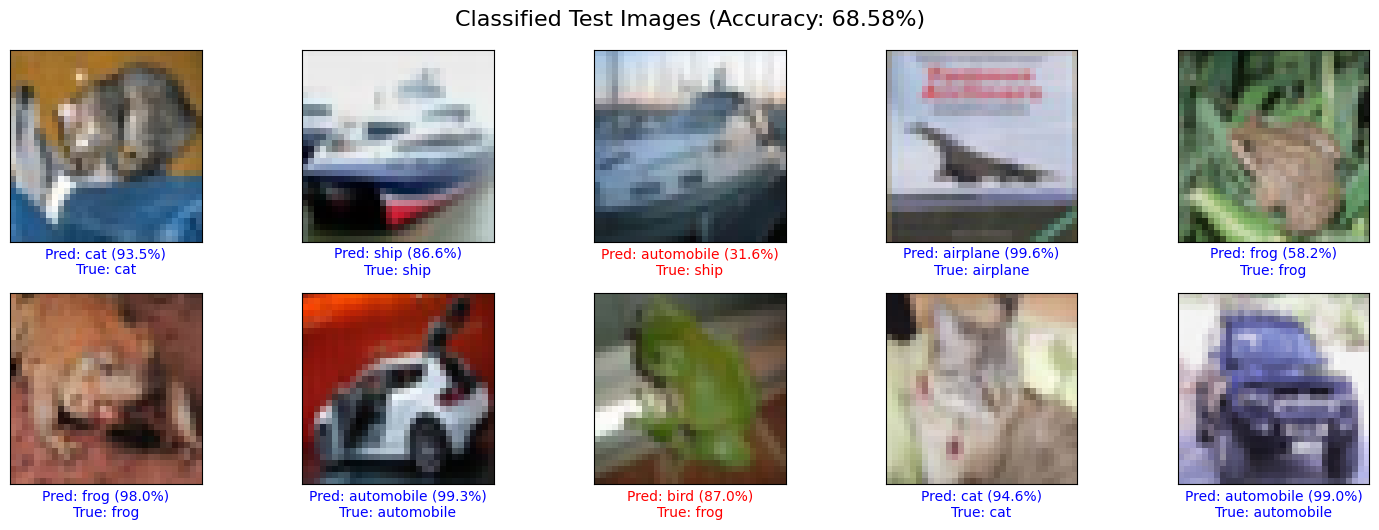

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load and normalize CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Define CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
   layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)  # Output layer (logits)
])

# Compile model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train model
history = model.fit(train_images, train_labels, epochs=15,
                    validation_data=(test_images, test_labels))

# Evaluate and print accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Add softmax for predictions
probability_model = tf.keras.Sequential([model, layers.Softmax()])
predictions = probability_model.predict(test_images)

# Plotting function for image with prediction
def plot_image(i, predictions_array, true_label, img):
    true_label = int(true_label)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    confidence = 100 * np.max(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Pred: {class_names[predicted_label]} ({confidence:.1f}%)\nTrue: {class_names[true_label]}", color=color)

# Display 10 classified test images
num_images = 10
plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plot_image(i, predictions[i], test_labels[i], test_images[i])
plt.tight_layout()
plt.suptitle(f"Classified Test Images (Accuracy: {test_acc*100:.2f}%)", fontsize=16, y=1.05)
plt.show()


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,688 (1.92 MB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,126 (1.28 MB)

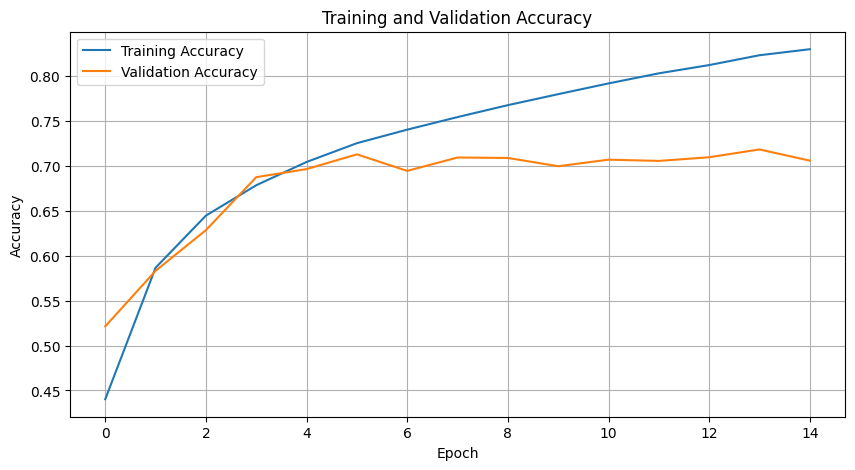

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
layers.Dropout(0.5)


<Dropout name=dropout_3, built=True>

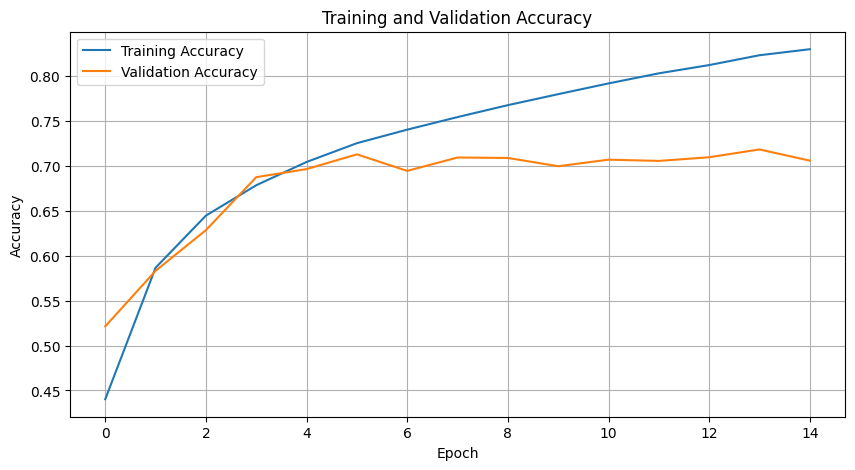

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Program 4: Build and demonstrate an autoencoder network using neural layers for data compression on
image dataset.

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 547ms/step - loss: 0.5965 - val_loss: 0.5634
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 271s 570ms/step - loss: 0.5623 - val_loss: 0.5615
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 209s 535ms/step - loss: 0.5596 - val_loss: 0.5593
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 267s 548ms/step - loss: 0.5579 - val_loss: 0.5584
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 211s 539ms/step - loss: 0.5570 - val_loss: 0.5587
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 543ms/step - loss: 0.5571 - val_loss: 0.5570
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 259s 536ms/step - loss: 0.5570 - val_loss: 0.5567
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 539ms/step - loss: 0.5568 - val_loss: 0.5570
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 210s 536ms/step - loss: 0.5561 - val_loss: 0.5569
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 255s 516ms/step - loss: 0.5551 - val_loss: 0.5556
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


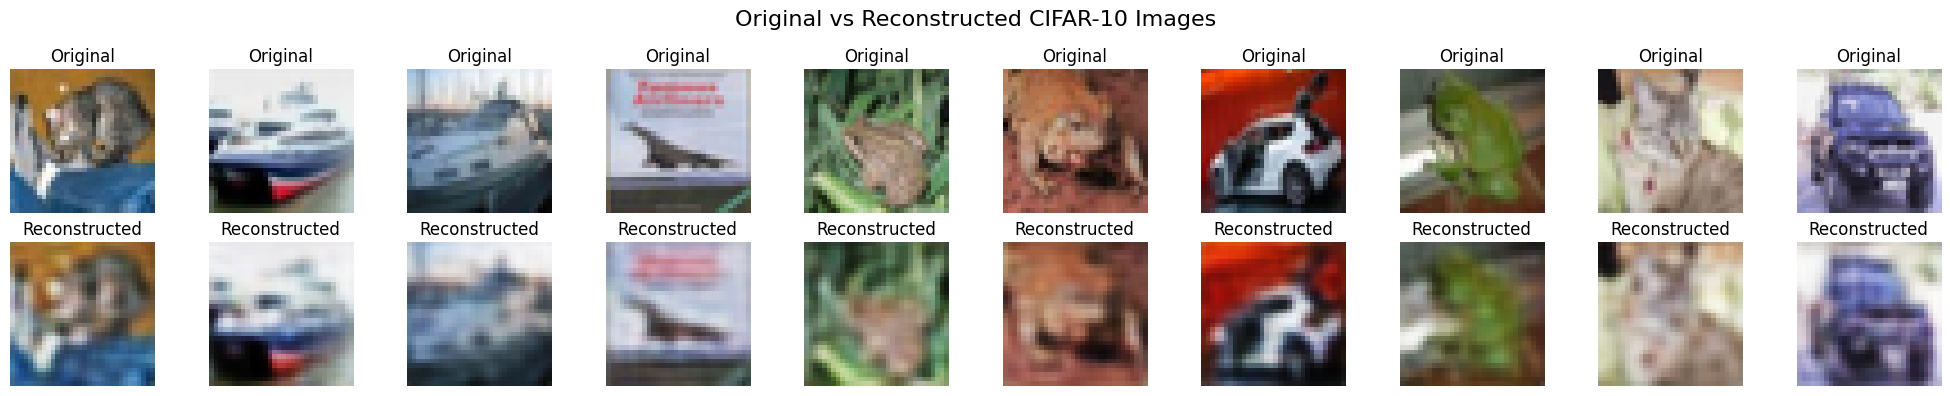

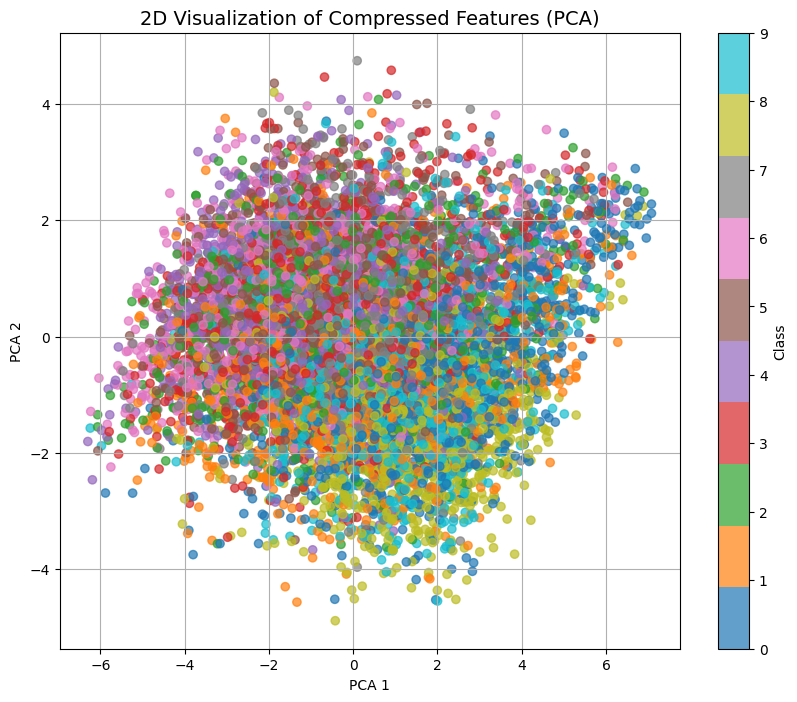

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Load and normalize CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0

# Define class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ----------- Autoencoder Model -----------
input_img = tf.keras.Input(shape=(32, 32, 3))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # Output shape: (8, 8, 64)

# Decoder
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder
autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

# Predict reconstruction
decoded_imgs = autoencoder.predict(x_test)

# ----------- Encoder Model to Extract Compressed Features -----------
encoder = tf.keras.Model(inputs=input_img, outputs=encoded)
compressed_features = encoder.predict(x_test)

# Flatten compressed features for PCA
compressed_flat = compressed_features.reshape(len(compressed_features), -1)

# Use PCA to reduce to 2D
pca = PCA(n_components=2)
compressed_2d = pca.fit_transform(compressed_flat)

# ----------- Visualization -----------

# Show 10 original vs reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs Reconstructed CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()

# Plot compressed 2D features
plt.figure(figsize=(10, 8))
scatter = plt.scatter(compressed_2d[:, 0], compressed_2d[:, 1], c=y_test.flatten(), cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.title("2D Visualization of Compressed Features (PCA)", fontsize=14)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.5980 - val_loss: 0.5637
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5618 - val_loss: 0.5599
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5593 - val_loss: 0.5593
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5574 - val_loss: 0.5577
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5572 - val_loss: 0.5574
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5561 - val_loss: 0.5569
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5557 - val_loss: 0.5563
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5557 - val_loss: 0.5559
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5554 - val_loss: 0.5556
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5547 - val_loss: 0.5555
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5543 - val_loss: 0.5554
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/s

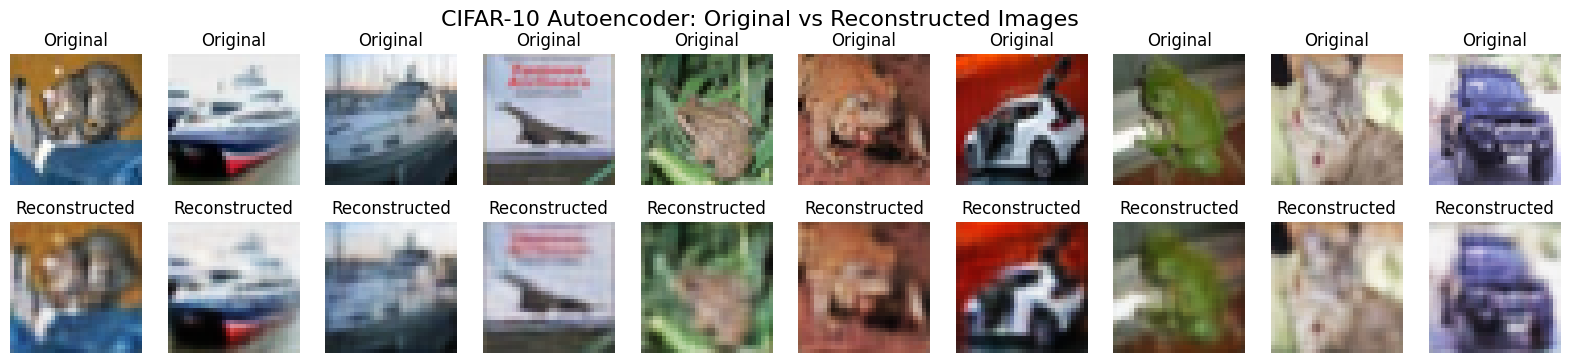

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load and normalize CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Define the CNN Autoencoder
input_img = tf.keras.Input(shape=(32, 32, 3))

# ----------- Encoder -----------
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# ----------- Decoder -----------
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Display original and reconstructed images
n = 10  # number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("CIFAR-10 Autoencoder: Original vs Reconstructed Images", fontsize=16)
plt.show()


In [ ]:
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,955 (886.55 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 151,304 (591.04 KB)

In [ ]:

decoded_imgs = autoencoder.predict(x_test)
print(decoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step
[[[[0.6010209  0.45530984 0.24865623]
   [0.65056485 0.45636833 0.19056496]
   [0.6423293  0.46044388 0.18941884]
   ...
   [0.55468506 0.33094338 0.13981913]
   [0.52809036 0.33400103 0.14046168]
   [0.49966568 0.31339508 0.16842622]]

  [[0.58654374 0.41257748 0.18509738]
   [0.6081383  0.3925244  0.13861199]
   [0.6224997  0.39867216 0.15203215]
   ...
   [0.58507526 0.35432553 0.13877219]
   [0.51745063 0.32665142 0.10891186]
   [0.47982085 0.3029291  0.11413902]]

  [[0.6164974  0.4273501  0.20368478]
   [0.6189603  0.42271832 0.16721322]
   [0.6429429  0.42494336 0.1761318 ]
   ...
   [0.5653341  0.3517282  0.14959164]
   [0.51569384 0.33741876 0.11932556]
   [0.48874608 0.2932155  0.11202053]]

  ...

  [[0.23423871 0.43987042 0.63722295]
   [0.17161769 0.36316618 0.61869353]
   [0.13181944 0.30421898 0.55214465]
   ...
   [0.12509198 0.320527   0.5245991 ]
   [0.07812521 0.22339578 0.4108222 ]
   [0.10798676 0.26421666 0.38718036]]

  

Program 7 : Write a program to enable pre-train models to classify a given image dataset


100%|██████████| 452M/452M [00:20<00:00, 23.0MB/s]

Extracting files...


📂 Dataset path: /root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1
✅ Train directory: /root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1/rock-paper-scissors/Rock-Paper-Scissors/train
✅ Validation directory: /root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1/rock-paper-scissors/Rock-Paper-Scissors/test
Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
Classes detected: {'paper': 0, 'rock': 1, 'scissors': 2}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 384ms/step - accuracy: 0.8795 - loss: 0.3148 - val_accuracy: 0.9301 - val_loss: 0.2113
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.9194 - val_loss: 0.2302
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9194 - val_loss: 0.1945
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9194 - val_loss: 0.2299
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 8.3135e-04 - val_accuracy: 0.9167 - val_loss: 0.2567
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9285 - loss: 0.2167
📊 Validation Loss: 0.2567, Validation Accuracy: 0.9167


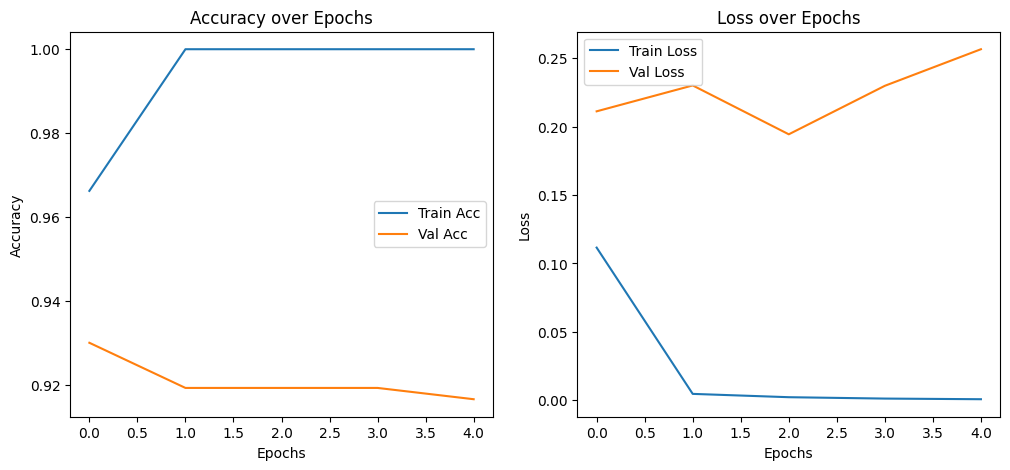

In [ ]:
import os
import kagglehub
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1) Download dataset once
dataset_path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")
print("📂 Dataset path:", dataset_path)

# 2) Auto-detect train & validation directories
def find_dataset_dirs(base_path):
    train_dir, val_dir = None, None
    for root, dirs, files in os.walk(base_path):
        if all(x in dirs for x in ["rock", "paper", "scissors"]):
            if "test" in root.lower():
                val_dir = root
            else:
                train_dir = root
    return train_dir, val_dir

train_dir, val_dir = find_dataset_dirs(dataset_path)

if train_dir is None or val_dir is None:
    raise ValueError("❌ Could not find train/validation directories automatically")

print("✅ Train directory:", train_dir)
print("✅ Validation directory:", val_dir)

# 3) Data generators
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

num_classes = train_gen.num_classes
print(f"Classes detected: {train_gen.class_indices}")

# 4) Build model (ResNet50 + custom head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze backbone

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 5) Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6) Train
history = model.fit(train_gen, validation_data=val_gen, epochs=5)

# 7) Evaluate
loss, acc = model.evaluate(val_gen)
print(f"📊 Validation Loss: {loss:.4f}, Validation Accuracy: {acc:.4f}")

# 8) Plot training history
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


Program 8
Simple Grid World Problem: Design a custom 2D grid world where the agent navigates from
a start position to a goal, avoiding obstacles. Environment: Custom grid (easily implemented
in Python)




In [ ]:
import numpy as np

class GridWorld:
    def __init__(self, size=5, start=(0, 0), goal=(4, 4), obstacles=None):
        self.size = size
        self.start = start
        self.goal = goal
        self.state = start
        self.actions = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }
        self.obstacles = obstacles if obstacles else [(1, 1), (2, 2), (3, 1)]

    def reset(self):
        self.state = self.start
        return self.state

    def is_valid(self, pos):
        x, y = pos
        if 0 <= x < self.size and 0 <= y < self.size and pos not in self.obstacles:
            return True
        return False

    def step(self, action):
        if action not in self.actions:
            raise ValueError("Invalid action")

        dx, dy = self.actions[action]
        new_state = (self.state[0] + dx, self.state[1] + dy)

        if not self.is_valid(new_state):
            reward = -100
            done = False
            return self.state, reward, done

        self.state = new_state
        if self.state == self.goal:
            reward = 100
            done = True
        else:
            reward = -1
            done = False

        return self.state, reward, done

    def render(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]
        for ox, oy in self.obstacles:
            grid[ox][oy] = '#'
        sx, sy = self.start
        gx, gy = self.goal
        ax, ay = self.state
        grid[sx][sy] = 'S'
        grid[gx][gy] = 'G'
        if self.state != self.start and self.state != self.goal:
            grid[ax][ay] = 'A'
        print("\n".join([" ".join(row) for row in grid]))
        print()

# Example usage
if __name__ == "__main__":
    env = GridWorld()
    env.reset()
    env.render()

    actions = ['right', 'right', 'down', 'down', 'down', 'right', 'right']
    for action in actions:
        state, reward, done = env.step(action)
        print(f"Action: {action}, State: {state}, Reward: {reward}, Done: {done}")
        env.render()
        if done:
            break


S . . . .
. # . . .
. . # . .
. # . . .
. . . . G

Action: right, State: (0, 1), Reward: -1, Done: False
S A . . .
. # . . .
. . # . .
. # . . .
. . . . G

Action: right, State: (0, 2), Reward: -1, Done: False
S . A . .
. # . . .
. . # . .
. # . . .
. . . . G

Action: down, State: (1, 2), Reward: -1, Done: False
S . . . .
. # A . .
. . # . .
. # . . .
. . . . G

Action: down, State: (1, 2), Reward: -100, Done: False
S . . . .
. # A . .
. . # . .
. # . . .
. . . . G

Action: down, State: (1, 2), Reward: -100, Done: False
S . . . .
. # A . .
. . # . .
. # . . .
. . . . G

Action: right, State: (1, 3), Reward: -1, Done: False
S . . . .
. # . A .
. . # . .
. # . . .
. . . . G

Action: right, State: (1, 4), Reward: -1, Done: False
S . . . .
. # . . A
. . # . .
. # . . .
. . . . G



***Extra Programs***

Extra Program 1: Build a simple RNN

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
vocab_size = 10000  # number of unique words to keep
maxlen = 100        # cut texts after this number of words

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences to ensure equal length
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# -----------------------------
# 2. Build RNN model
# -----------------------------
model = Sequential([
    Embedding(vocab_size, 32, input_length=maxlen),  # word embeddings
    SimpleRNN(64, activation='tanh'),               # RNN layer
    Dense(1, activation='sigmoid')                  # output layer
])

# -----------------------------
# 3. Compile the model
# -----------------------------
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# -----------------------------
# 4. Train the model
# -----------------------------
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2)

# -----------------------------
# 5. Evaluate the model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.3f}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5572 - loss: 0.6736 - val_accuracy: 0.7756 - val_loss: 0.4743
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8281 - loss: 0.3902 - val_accuracy: 0.8170 - val_loss: 0.4343
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8964 - loss: 0.2634 - val_accuracy: 0.8184 - val_loss: 0.4271
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9545 - loss: 0.1367 - val_accuracy: 0.8084 - val_loss: 0.5456
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9820 - loss: 0.0596 - val_accuracy: 0.8056 - val_loss: 0.6669
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8064 - loss: 0.6750

Test Accuracy: 0.808


Extra Program 2: Develop Simple LSTM Model

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6423 - loss: 0.6113 - val_accuracy: 0.8452 - val_loss: 0.3601
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8905 - loss: 0.2826 - val_accuracy: 0.8745 - val_loss: 0.3112
[0.5050014853477478, 0.2737466096878052]
[0.7433199882507324, 0.8926799893379211]


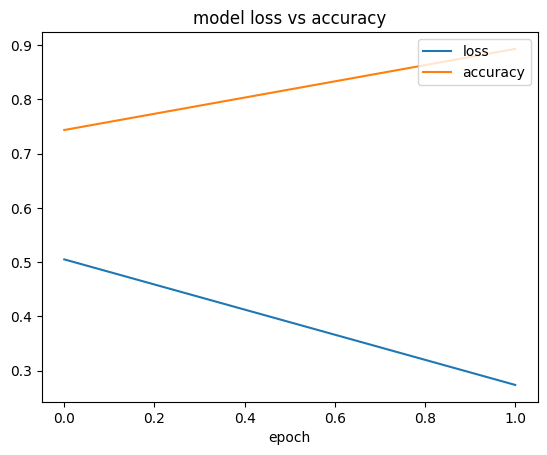

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.utils import pad_sequences
from keras.layers import Dropout
from keras.layers import  Dense, Embedding, LSTM, Bidirectional
from keras.datasets import imdb
(x_train, y_train),(x_test, y_test) = imdb.load_data(num_words=10000)
maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
y_test = np.array(y_test)
y_train = np.array(y_train)
n_unique_words=10000
batch_size=250
model = Sequential()
model.add(Embedding(n_unique_words, 128, input_length=maxlen))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history=model.fit(x_train, y_train,
           batch_size=batch_size,
           epochs=2,
           validation_data=[x_test, y_test])
print(history.history['loss'])
print(history.history['accuracy'])
from matplotlib import pyplot
pyplot.plot(history.history['loss'])
pyplot.plot(history.history['accuracy'])
pyplot.title('model loss vs accuracy')
pyplot.xlabel('epoch')
pyplot.legend(['loss', 'accuracy'], loc='upper right')
pyplot.show()